# Laboratorio 9 — Redes Neuronales Artificiales (RNA)
## CC3074 Minería de Datos · SmartStay Advisors · Semestre I 2026

**Objetivo:** Construir modelos de RNA para (1) clasificar el precio de listings Airbnb en categorías Barato / Medio / Caro y (2) predecir el precio numérico, comparando ambos tipos contra los algoritmos de laboratorios anteriores.

## 0. Carga de librerías y configuración

In [11]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import pyreadr

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.neural_network import MLPClassifier, MLPRegressor

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


SEED = 42
np.random.seed(SEED)

sns.set(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

print("✔ Librerías cargadas correctamente")

✔ Librerías cargadas correctamente


## Carga y exploración inicial del dataset

In [ ]:
# Cargar dataset
result = pyreadr.read_r('../data/listings.RData')

print(result.keys())

df = list(result.values())[0]

print("Shape inicial:", df.shape)
df.head()

odict_keys(['listings'])
Shape inicial: (171748, 80)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas"
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas"


In [4]:
### Revisión general del dataset

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores nulos:")
print(df.isna().sum().sort_values(ascending=False).head(10))



Tipos de datos:
id                                              float64
listing_url                                         str
scrape_id                                       float64
last_scraped                                        str
source                                              str
                                                 ...   
calculated_host_listings_count_entire_homes       int32
calculated_host_listings_count_private_rooms      int32
calculated_host_listings_count_shared_rooms       int32
reviews_per_month                               float64
city                                                str
Length: 80, dtype: object

Valores nulos:
calendar_updated                171748
estimated_revenue_l365d          95502
price                            89381
neighbourhood_group_cleansed     50683
review_scores_value              40328
review_scores_location           40328
review_scores_checkin            40324
review_scores_accuracy           40312
review_scores

In [ ]:
## Limpieza y preparación de la variable precio
print("Filas antes de limpieza:", len(df))

df['price'] = df['price'].astype(str)\
    .str.replace('$', '', regex=False)\
    .str.replace(',', '', regex=False)

df['price'] = pd.to_numeric(df['price'], errors='coerce')

df = df[df['price'].notna() & (df['price'] > 0)].copy()

print("Filas después de limpieza:", len(df))
print(df['price'].describe())


Filas antes de limpieza: 171748
Filas después de limpieza: 76246
count    76246.000000
mean       750.509220
std       4250.606945
min          8.000000
25%        120.000000
50%        193.000000
75%        326.000000
max      50123.000000
Name: price, dtype: float64


In [6]:
print(len(df))
print(df['price'].describe())

76246
count    76246.000000
mean       750.509220
std       4250.606945
min          8.000000
25%        120.000000
50%        193.000000
75%        326.000000
max      50123.000000
Name: price, dtype: float64


In [ ]:
#Preparación final del dataset
# Calcular tertiles
q33 = df['price'].quantile(1/3)
q67 = df['price'].quantile(2/3)

# Función de categorización
def categorize_price(p):
    if p <= q33:
        return 'Barato'
    elif p <= q67:
        return 'Medio'
    else:
        return 'Caro'

# Crear variable categórica
df['price_category'] = df['price'].apply(categorize_price)

# Ver resultados
print("Umbrales:")
print(f"Barato <= {q33:.2f}")
print(f"Medio <= {q67:.2f}")

print("\nDistribución:")
print(df['price_category'].value_counts())

Umbrales:
Barato <= 143.00
Medio <= 268.00

Distribución:
price_category
Barato    25689
Caro      25404
Medio     25153
Name: count, dtype: int64


## 1. Use los mismos conjuntos de entrenamiento y prueba

In [14]:
## el punto dos es la parte de arriba que se crearon de primero las variables y luego la pusieron las partes de entrenamiento

In [ ]:
# 1.1 Selección de variables (features)
# Features numéricas principales
features = [
    'latitude','longitude','accommodates','bedrooms','beds',
    'minimum_nights','number_of_reviews','review_scores_rating',
    'availability_365'
]

# Verificar que existan
features = [f for f in features if f in df.columns]

print("Features utilizadas:", features)
print("Cantidad:", len(features))

Features utilizadas: ['latitude', 'longitude', 'accommodates', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'availability_365']
Cantidad: 9


In [ ]:
# 1.2 Creación del dataset final
# Dataset final para modelado
df_model = df[features + ['price', 'price_category']].dropna().copy()

print("Filas para modelado:", len(df_model))
df_model.head()

Filas para modelado: 62731


,latitude,longitude,accommodates,bedrooms,beds,minimum_nights,number_of_reviews,review_scores_rating,availability_365,price,price_category
0,30.26057,-97.73441,3,1,2,2,708,4.85,328,97.0,Barato
1,30.26034,-97.76487,2,1,2,3,339,4.97,316,160.0,Medio
2,30.23466,-97.73682,2,1,1,4,54,4.57,88,38.0,Barato
3,30.26098,-97.73072,3,2,2,15,19,5.00,321,145.0,Medio
4,30.23614,-97.73225,2,1,1,30,56,4.95,211,58.0,Barato


In [10]:
# 1.3 División en entrenamiento y prueba (80/20)
X = df_model[features]
y_class = df_model['price_category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (50184, 9)
Test: (12547, 9)


In [12]:
# 1.4 Escalado de variables (requerido para RNA)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("✔ Datos escalados")

✔ Datos escalados


In [13]:
print(len(df_model))
print(X_train.shape)

62731
(50184, 9)


## 3. Genere dos modelos de RNA de clasificación con diferentes topologías y funciones de activación

In [15]:
# 3. Modelos de clasificación con Redes Neuronales (RNA)
# Modelo 1: arquitectura simple
mlp1 = MLPClassifier(
    hidden_layer_sizes=(32,),   # 1 capa, 32 neuronas
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

# Entrenamiento
mlp1.fit(X_train, y_train)

# Predicción
y_pred_1 = mlp1.predict(X_test)

# Evaluación
print("Accuracy Modelo 1:", accuracy_score(y_test, y_pred_1))
print("\nReporte:")
print(classification_report(y_test, y_pred_1))

Accuracy Modelo 1: 0.6493185622061051

Reporte:
              precision    recall  f1-score   support

      Barato       0.70      0.77      0.73      4514
        Caro       0.71      0.66      0.68      3788
       Medio       0.54      0.52      0.53      4245

    accuracy                           0.65     12547
   macro avg       0.65      0.65      0.65     12547
weighted avg       0.65      0.65      0.65     12547



In [16]:
# 3.2 Modelo 2 — Red neuronal más compleja (tanh)
# Modelo 2: arquitectura más profunda
mlp2 = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # 2 capas
    activation='tanh',
    solver='adam',
    max_iter=300,
    random_state=42
)

# Entrenamiento
mlp2.fit(X_train, y_train)

# Predicción
y_pred_2 = mlp2.predict(X_test)

# Evaluación
print("Accuracy Modelo 2:", accuracy_score(y_test, y_pred_2))
print("\nReporte:")
print(classification_report(y_test, y_pred_2))

Accuracy Modelo 2: 0.6601578066470073

Reporte:
              precision    recall  f1-score   support

      Barato       0.73      0.74      0.74      4514
        Caro       0.70      0.70      0.70      3788
       Medio       0.55      0.54      0.54      4245

    accuracy                           0.66     12547
   macro avg       0.66      0.66      0.66     12547
weighted avg       0.66      0.66      0.66     12547



In [17]:
## aca tambien se analizo el punto 4 con los codigos de 
# y_pred_1 = mlp1.predict(X_test)
# y_pred_2 = mlp2.predict(X_test)

## 5. Evaluación de modelos: matrices de confusión

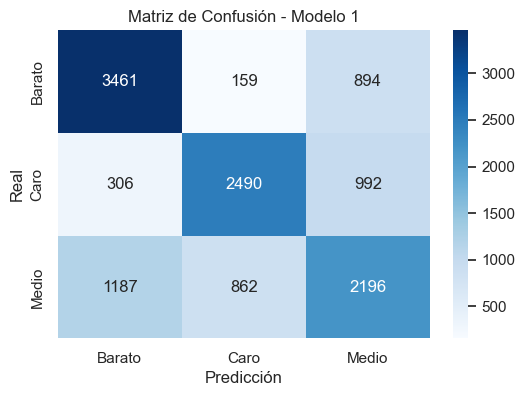

In [18]:
### 5.1 Matriz de confusión — Modelo 1
cm1 = confusion_matrix(y_test, y_pred_1)

plt.figure(figsize=(6,4))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=mlp1.classes_,
            yticklabels=mlp1.classes_)
plt.title("Matriz de Confusión - Modelo 1")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

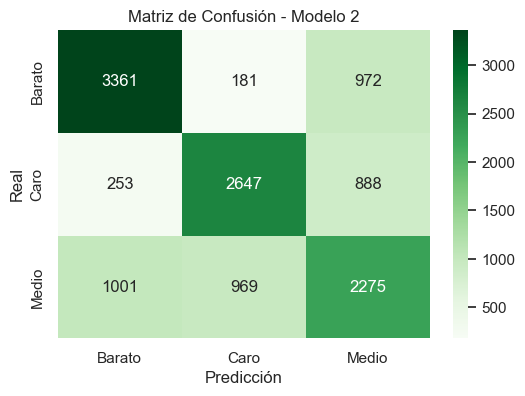

In [19]:
### 5.2 Matriz de confusión — Modelo 2
cm2 = confusion_matrix(y_test, y_pred_2)

plt.figure(figsize=(6,4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=mlp2.classes_,
            yticklabels=mlp2.classes_)
plt.title("Matriz de Confusión - Modelo 2")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()